# CauKer: Causal-Kernel Synthetic Time Series

[CauKer](https://arxiv.org/abs/2508.02879) (Xie et al., 2025) generates **synthetic multivariate time series** for **classification pre-training** of time-series foundation models (TSFMs).
It couples a **Gaussian Process (GP) kernel bank** with a **Structural Causal Model (SCM)** so that generated series carry controllable causal structure and diverse temporal patterns.

<p align="center">
<img width="70%" align="middle" src="../../docs/source/_static/CauKer.jpg">
</p>

## Motivation

- Large TSFMs need abundant labeled series; real labeled data are scarce.
- Pure noise or i.i.d. sampling lacks temporal / causal structure useful for representation learning.
- CauKer builds series by (1) composing GP kernels, (2) drawing root signals from GPs, and (3) propagating them through a random DAG with nonlinear edge activations.

## Algorithm 1 (five steps)

1. **Kernel bank** — sample $K \sim U(1, K_{\max})$ kernels from a bank of base kernels / variants.
2. **Kernel composition** — combine sampled kernels with random $+$ / $\times$ operators into a composite covariance.
3. **Root-node GP** — for each root of the DAG, draw a signal from $\mathrm{GP}(m(\cdot), k_{\mathrm{comp}})$ (mean from a mean-function bank).
4. **Edge activations** — sample a nonlinear activation for every DAG edge.
5. **DAG propagation** — topological pass: each non-root node aggregates activated parent signals (+ noise); finally select $d$ observed nodes.

**Output shape:** $(d, L)$ — $d$ observed channels, $L$ time steps.
**Optional labels:** pass `n_classes` (or use `generate_batch`) to obtain classification targets for pre-training.

Reference: Xie, S., et al. (2025). *CauKer*. arXiv:2508.02879, Algorithm 1.

**Adjacency convention in this notebook:** `adjacency[i, j] = 1` means a directed edge **i → j**.

In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join("..", "..")))

from s2generator.scm import CaukerPipeline
from s2generator.utils import (
    plot_univariate_time_series,
    plot_multivariate_time_series,
    plot_adjacency_matrix,
    plot_graph,
    plot_correlation,
    multivariate_correlation,
)


def edges_to_adjacency(n_nodes: int, edge_list) -> np.ndarray:
    # Rebuild a (V, V) adjacency from CauKer metadata edge_list (parent, child).
    adj = np.zeros((n_nodes, n_nodes), dtype=int)
    for parent, child in edge_list:
        adj[int(parent), int(child)] = 1
    return adj


rng = np.random.RandomState(0)
pipe = CaukerPipeline(target_length=256)
print(pipe)
print("n kernels:", pipe.n_kernels, "| n mean functions:", pipe.n_mean_functions)

CaukerPipeline
n kernels: 36 | n mean functions: 4


## 1. Univariate series (`d = 1`)

`generate` returns shape $(d, L)$. With `num_channels=1` this matches the common univariate CauKer pre-training setup.

univariate shape: (1, 256)


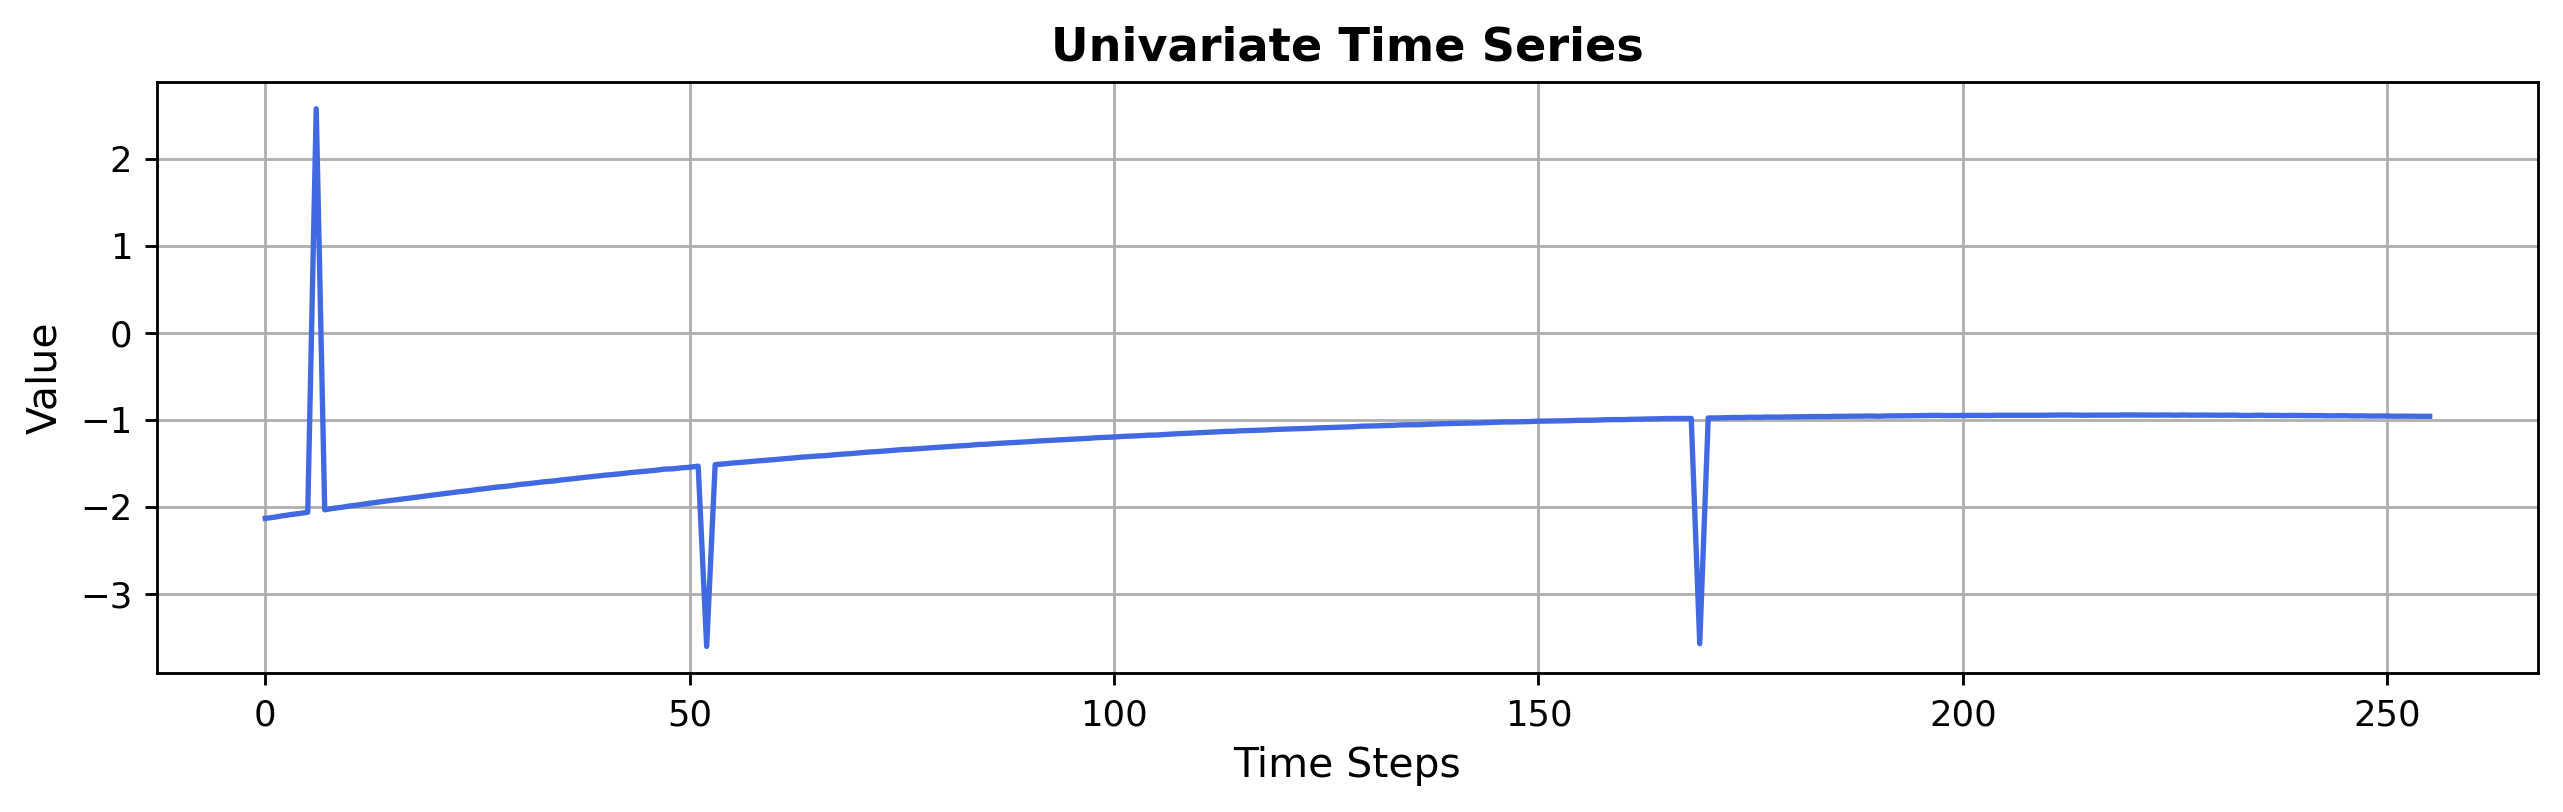

In [2]:
x_uni = pipe.generate(rng, seq_length=256, num_channels=1)
print("univariate shape:", x_uni.shape)  # (1, L)

fig = plot_univariate_time_series(x_uni)
plt.show()

## 2. Multivariate series on a random DAG

With `return_metadata=True`, CauKer returns graph statistics (`edge_list`, `n_total_nodes`, observed / root nodes). We reconstruct the adjacency and visualize both the graph and the $(d, L)$ series.

d=3 | series (3, 256) | V=8 | E=13 | roots=[2, 3, 5, 6] | observed=[1, 5, 6]


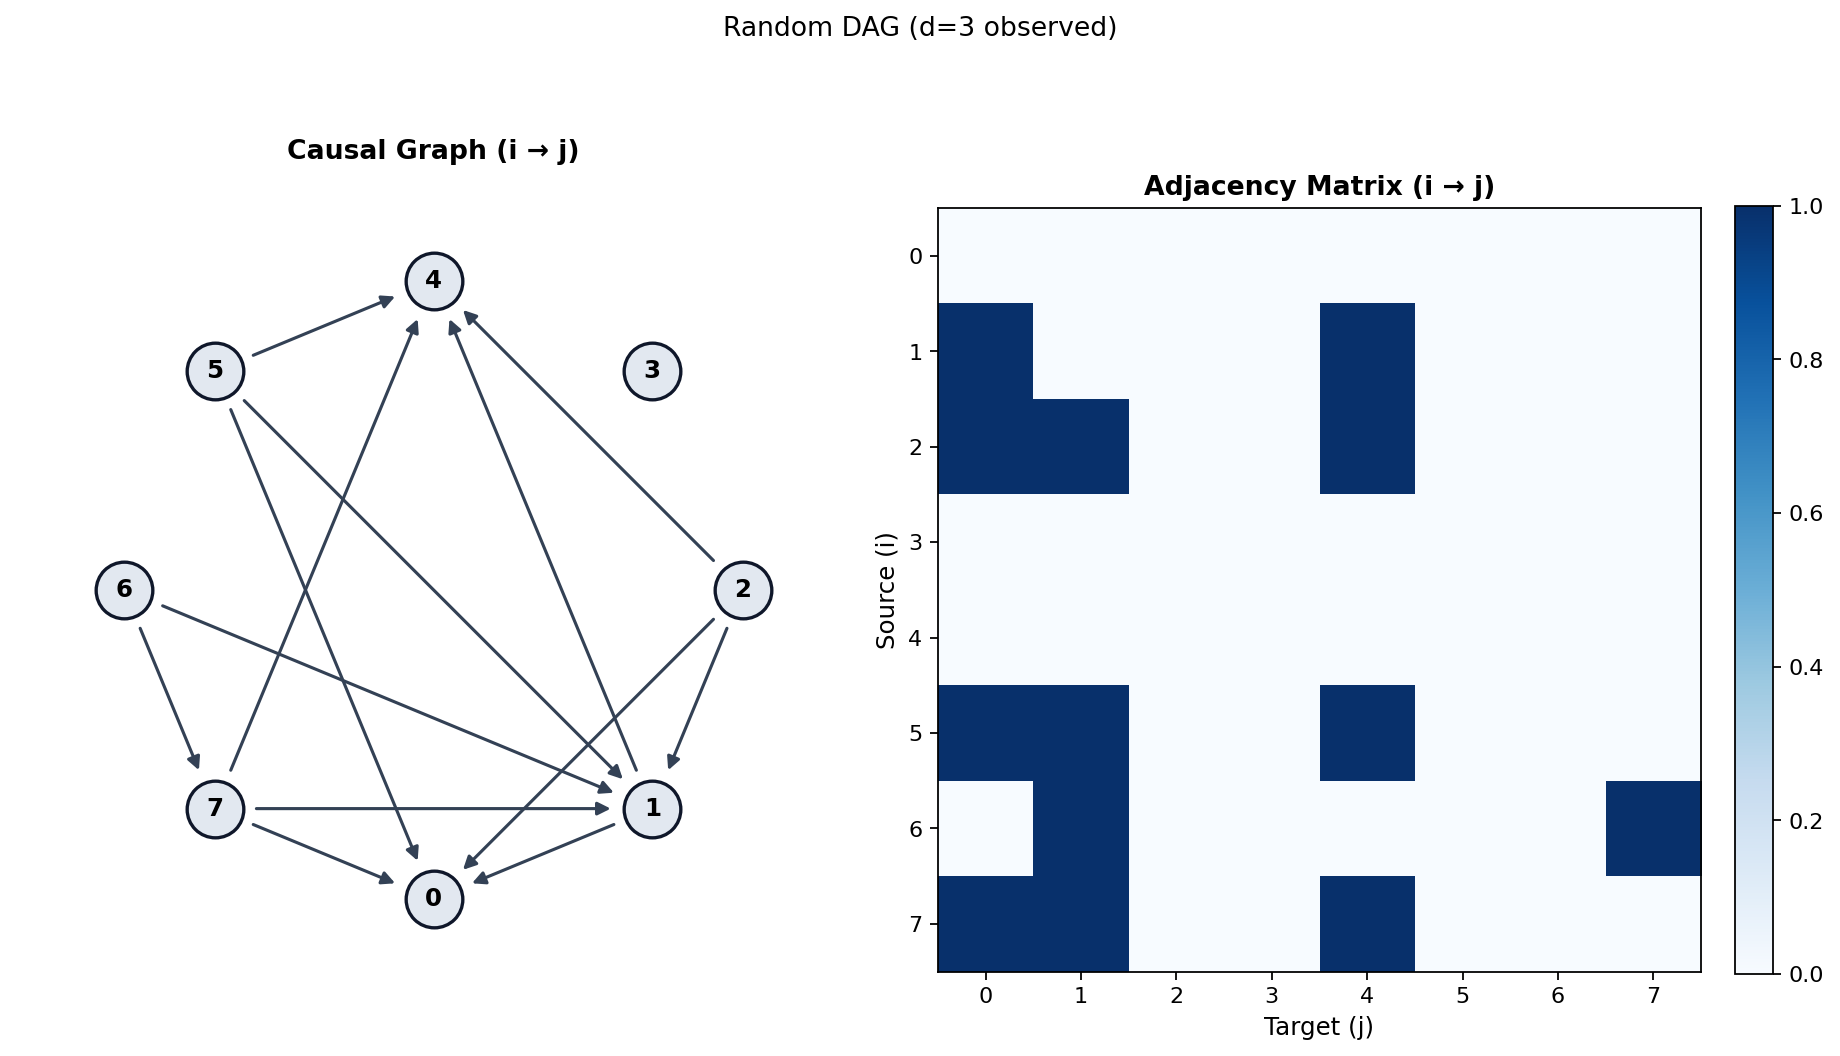

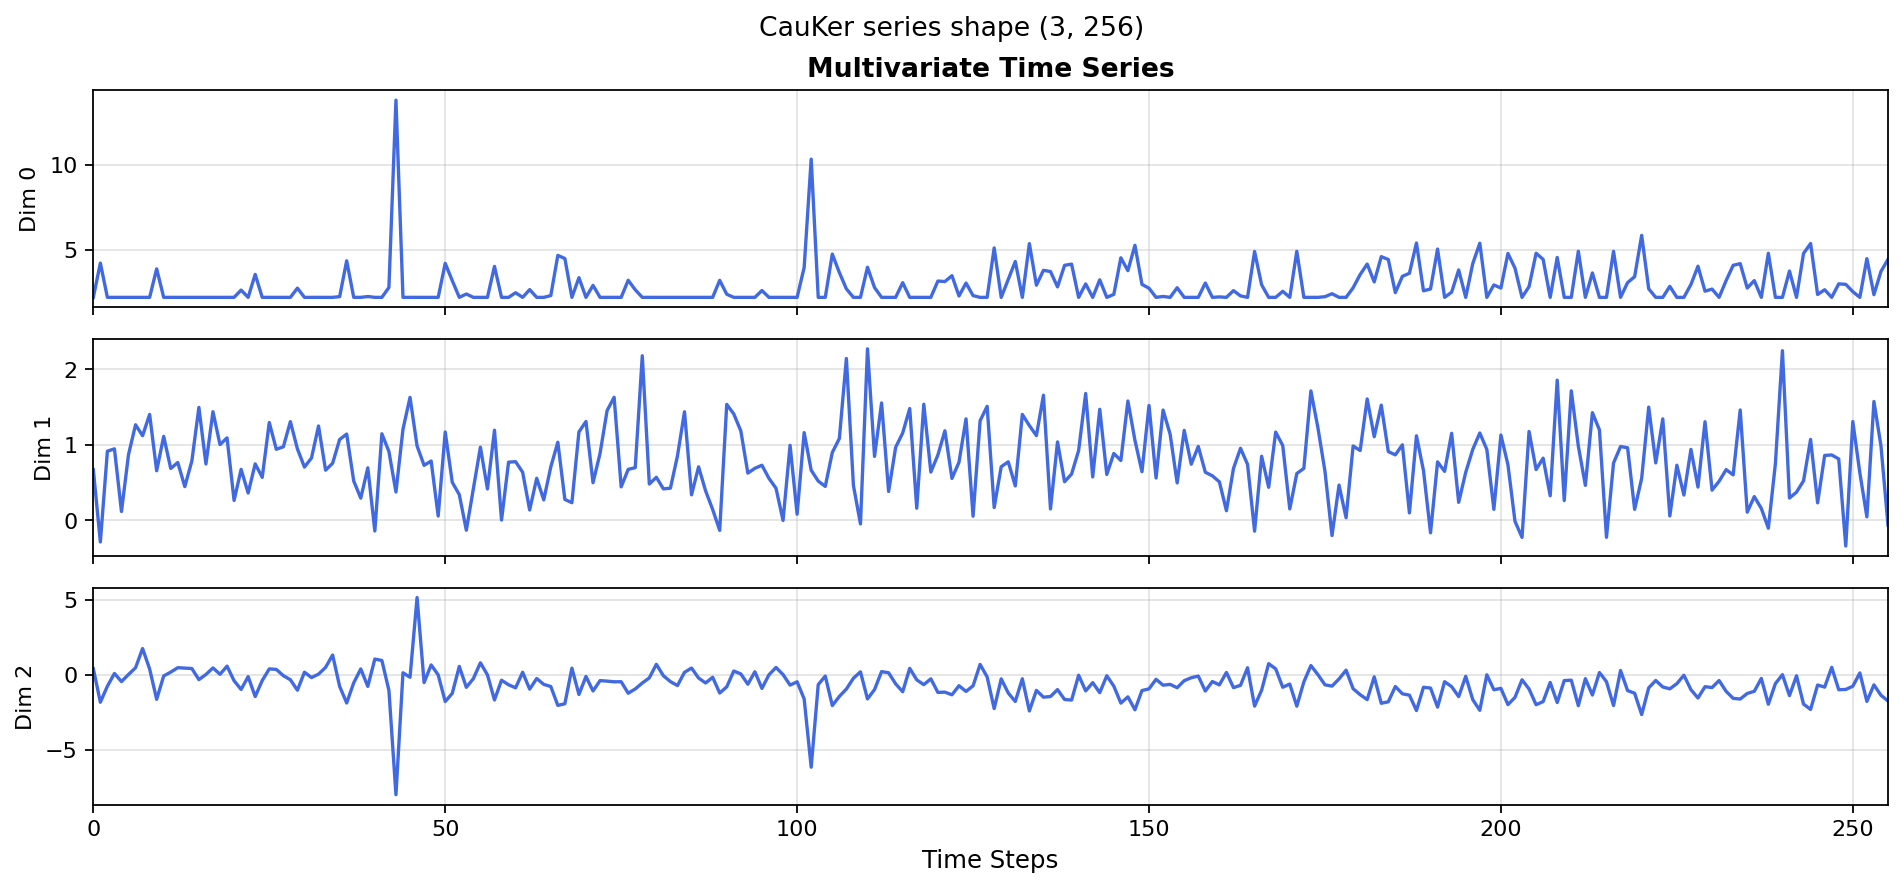

d=6 | series (6, 256) | V=11 | E=17 | roots=[0, 8] | observed=[1, 2, 4, 7, 9, 10]


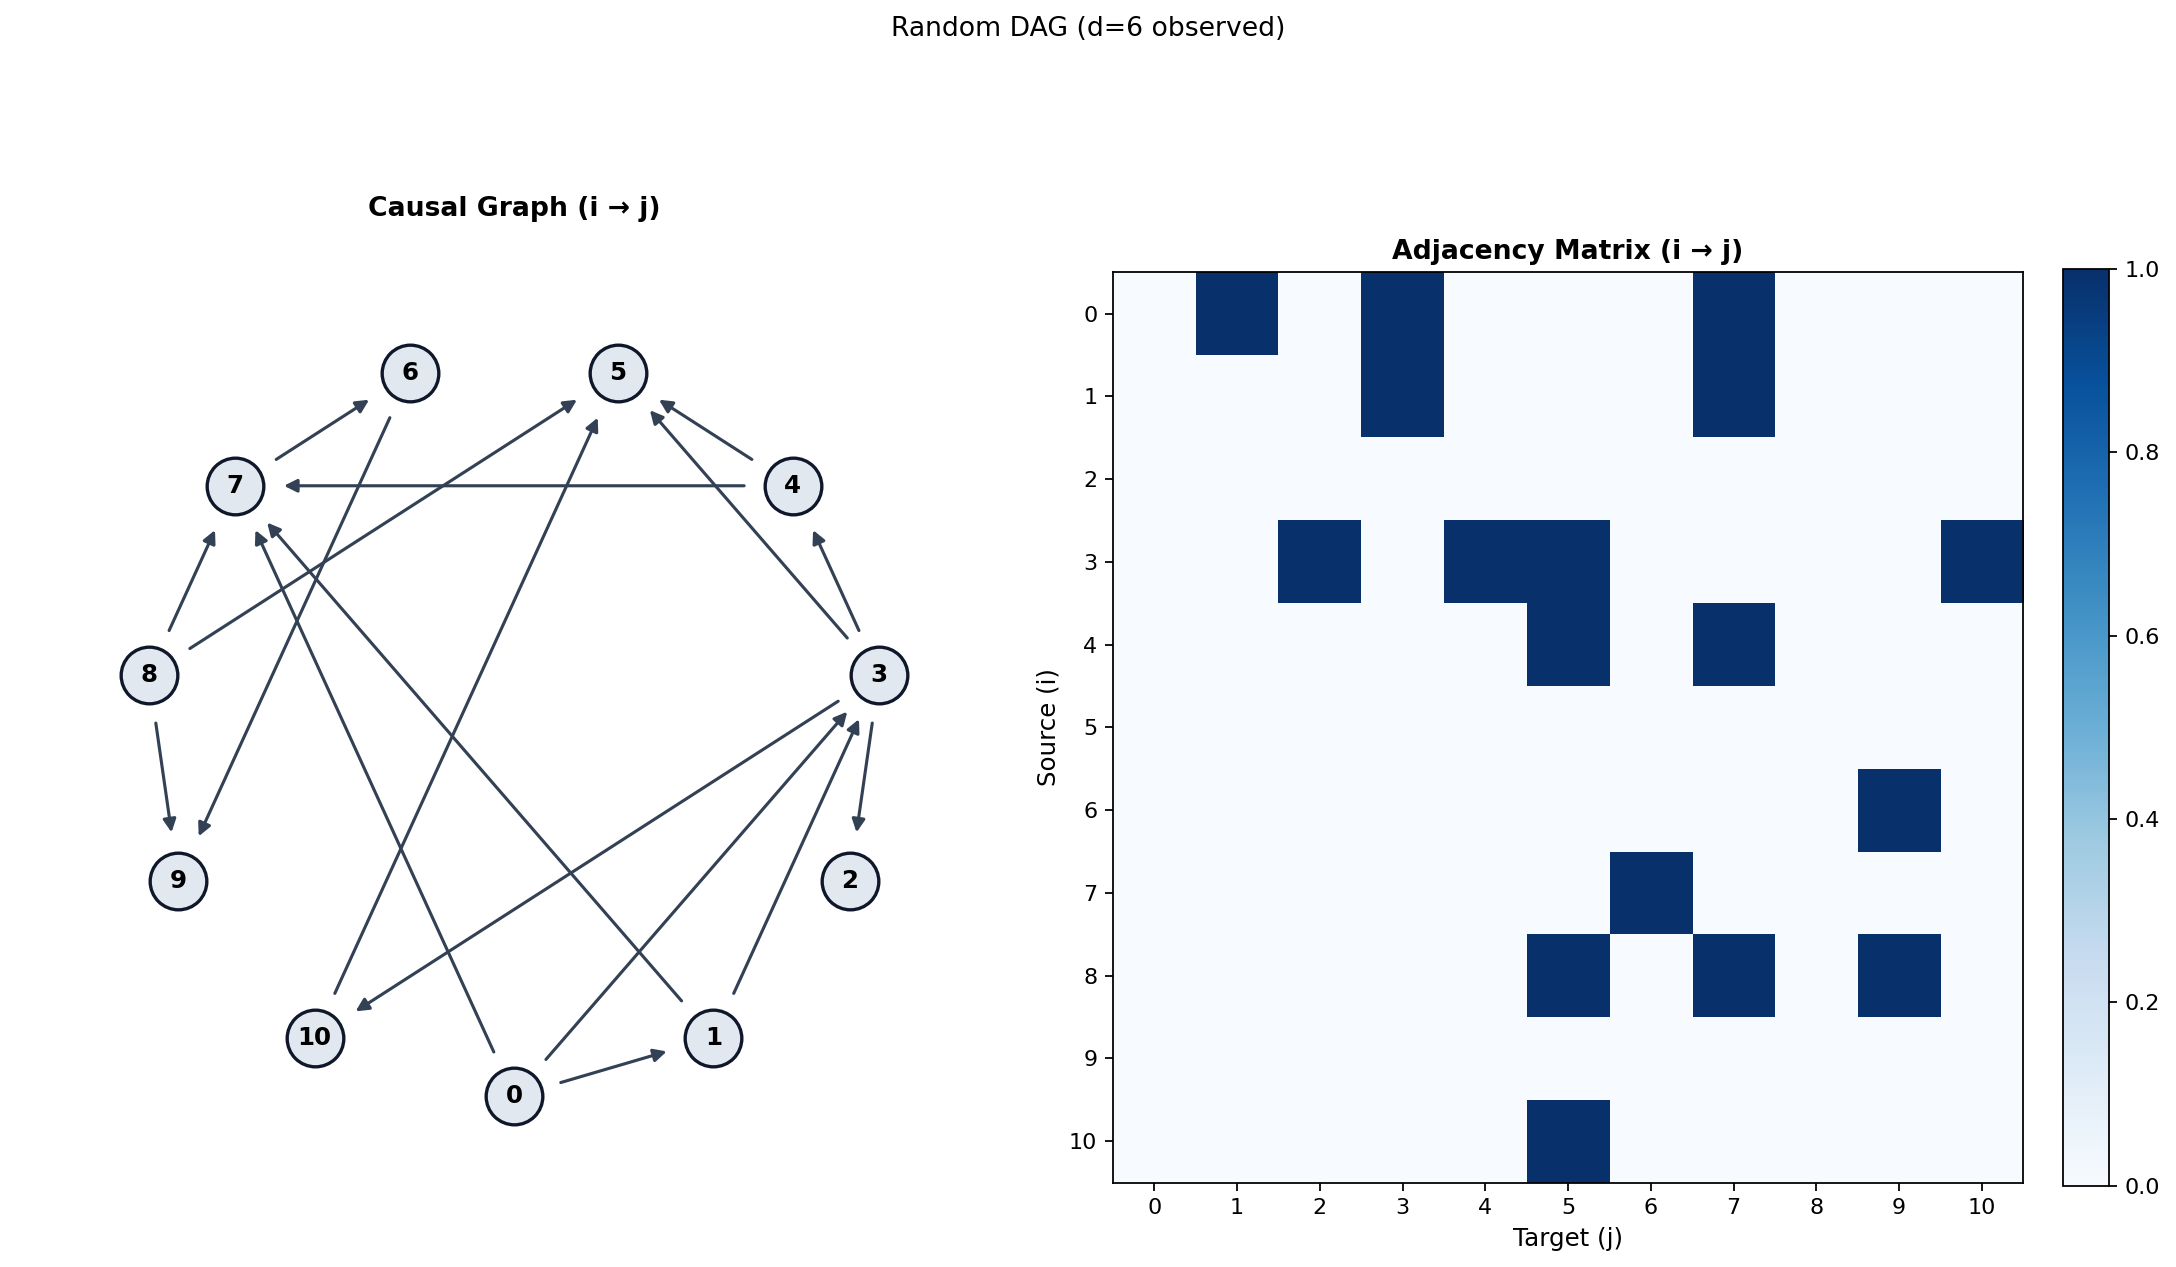

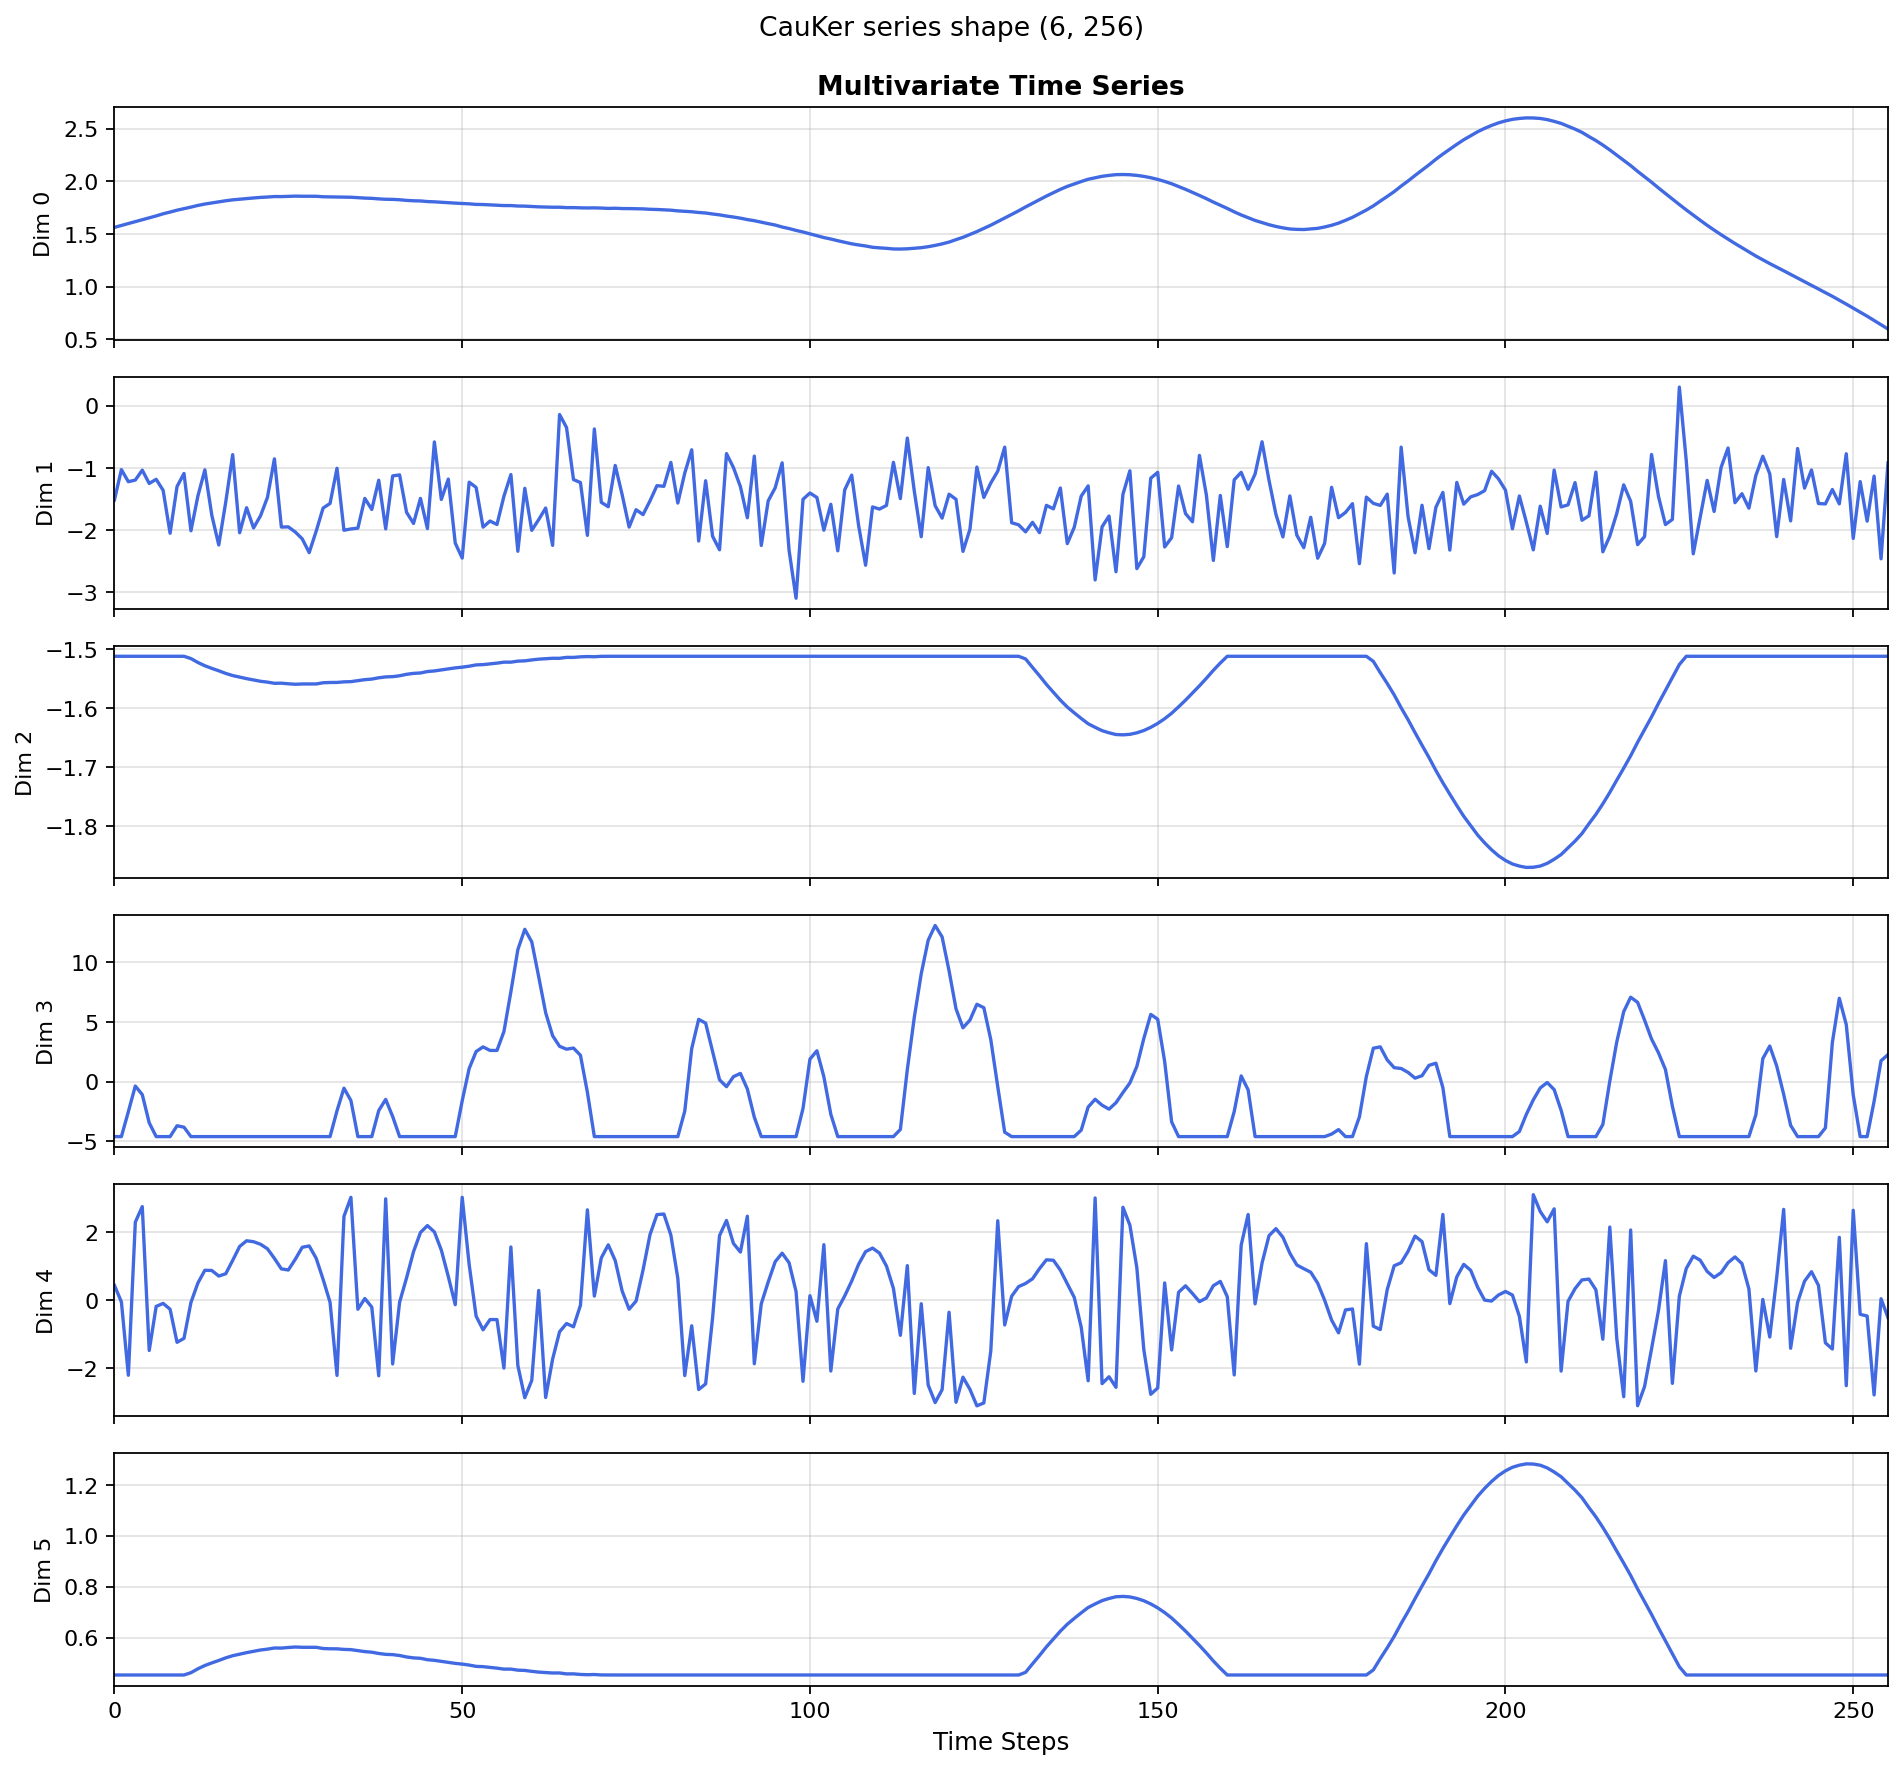

In [3]:
rng = np.random.RandomState(1)

for d in (3, 6):
    x, meta = pipe.generate(rng, seq_length=256, num_channels=d, return_metadata=True)
    adj = edges_to_adjacency(meta["n_total_nodes"], meta["edge_list"])
    print(
        f"d={d} | series {x.shape} | V={meta['n_total_nodes']} | "
        f"E={meta['n_edges']} | roots={meta['root_nodes']} | observed={meta['observed_nodes']}"
    )

    fig_g = plot_graph(adj, show_matrix=True)
    fig_g.suptitle(f"Random DAG (d={d} observed)", y=1.02)
    plt.show()

    fig_x = plot_multivariate_time_series(x)
    fig_x.suptitle(f"CauKer series shape {x.shape}", y=1.02)
    plt.show()

## 3. Custom causal graphs: chain / fork / collider

Supply a fixed `adjacency` to control the SCM topology. Below we use three canonical motifs, generate series with all nodes observed, and plot **graph + matrix** then the multivariate series.

chain: adjacency (5, 5), series (5, 256)


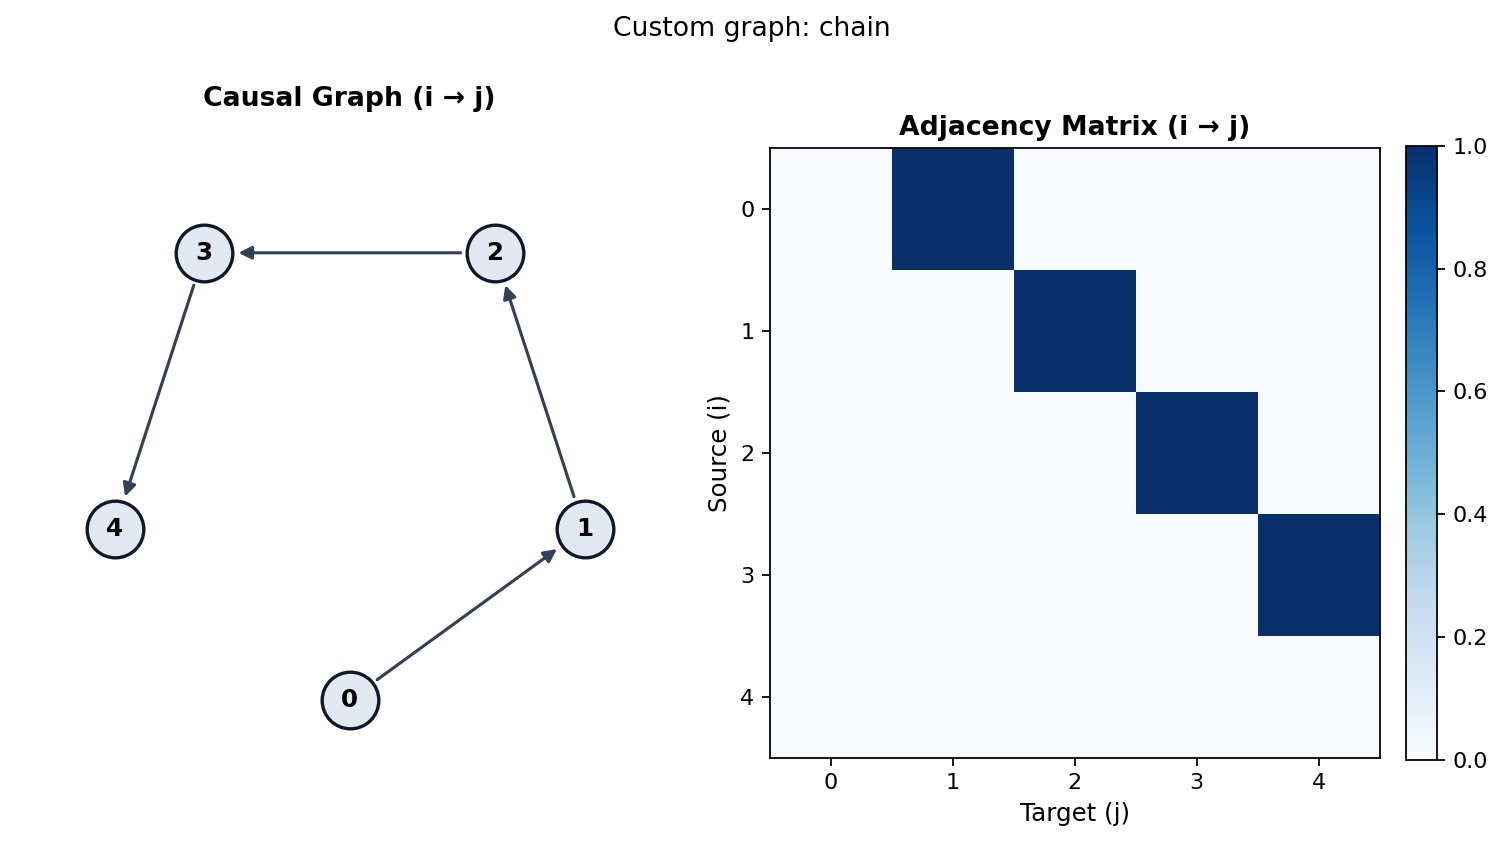

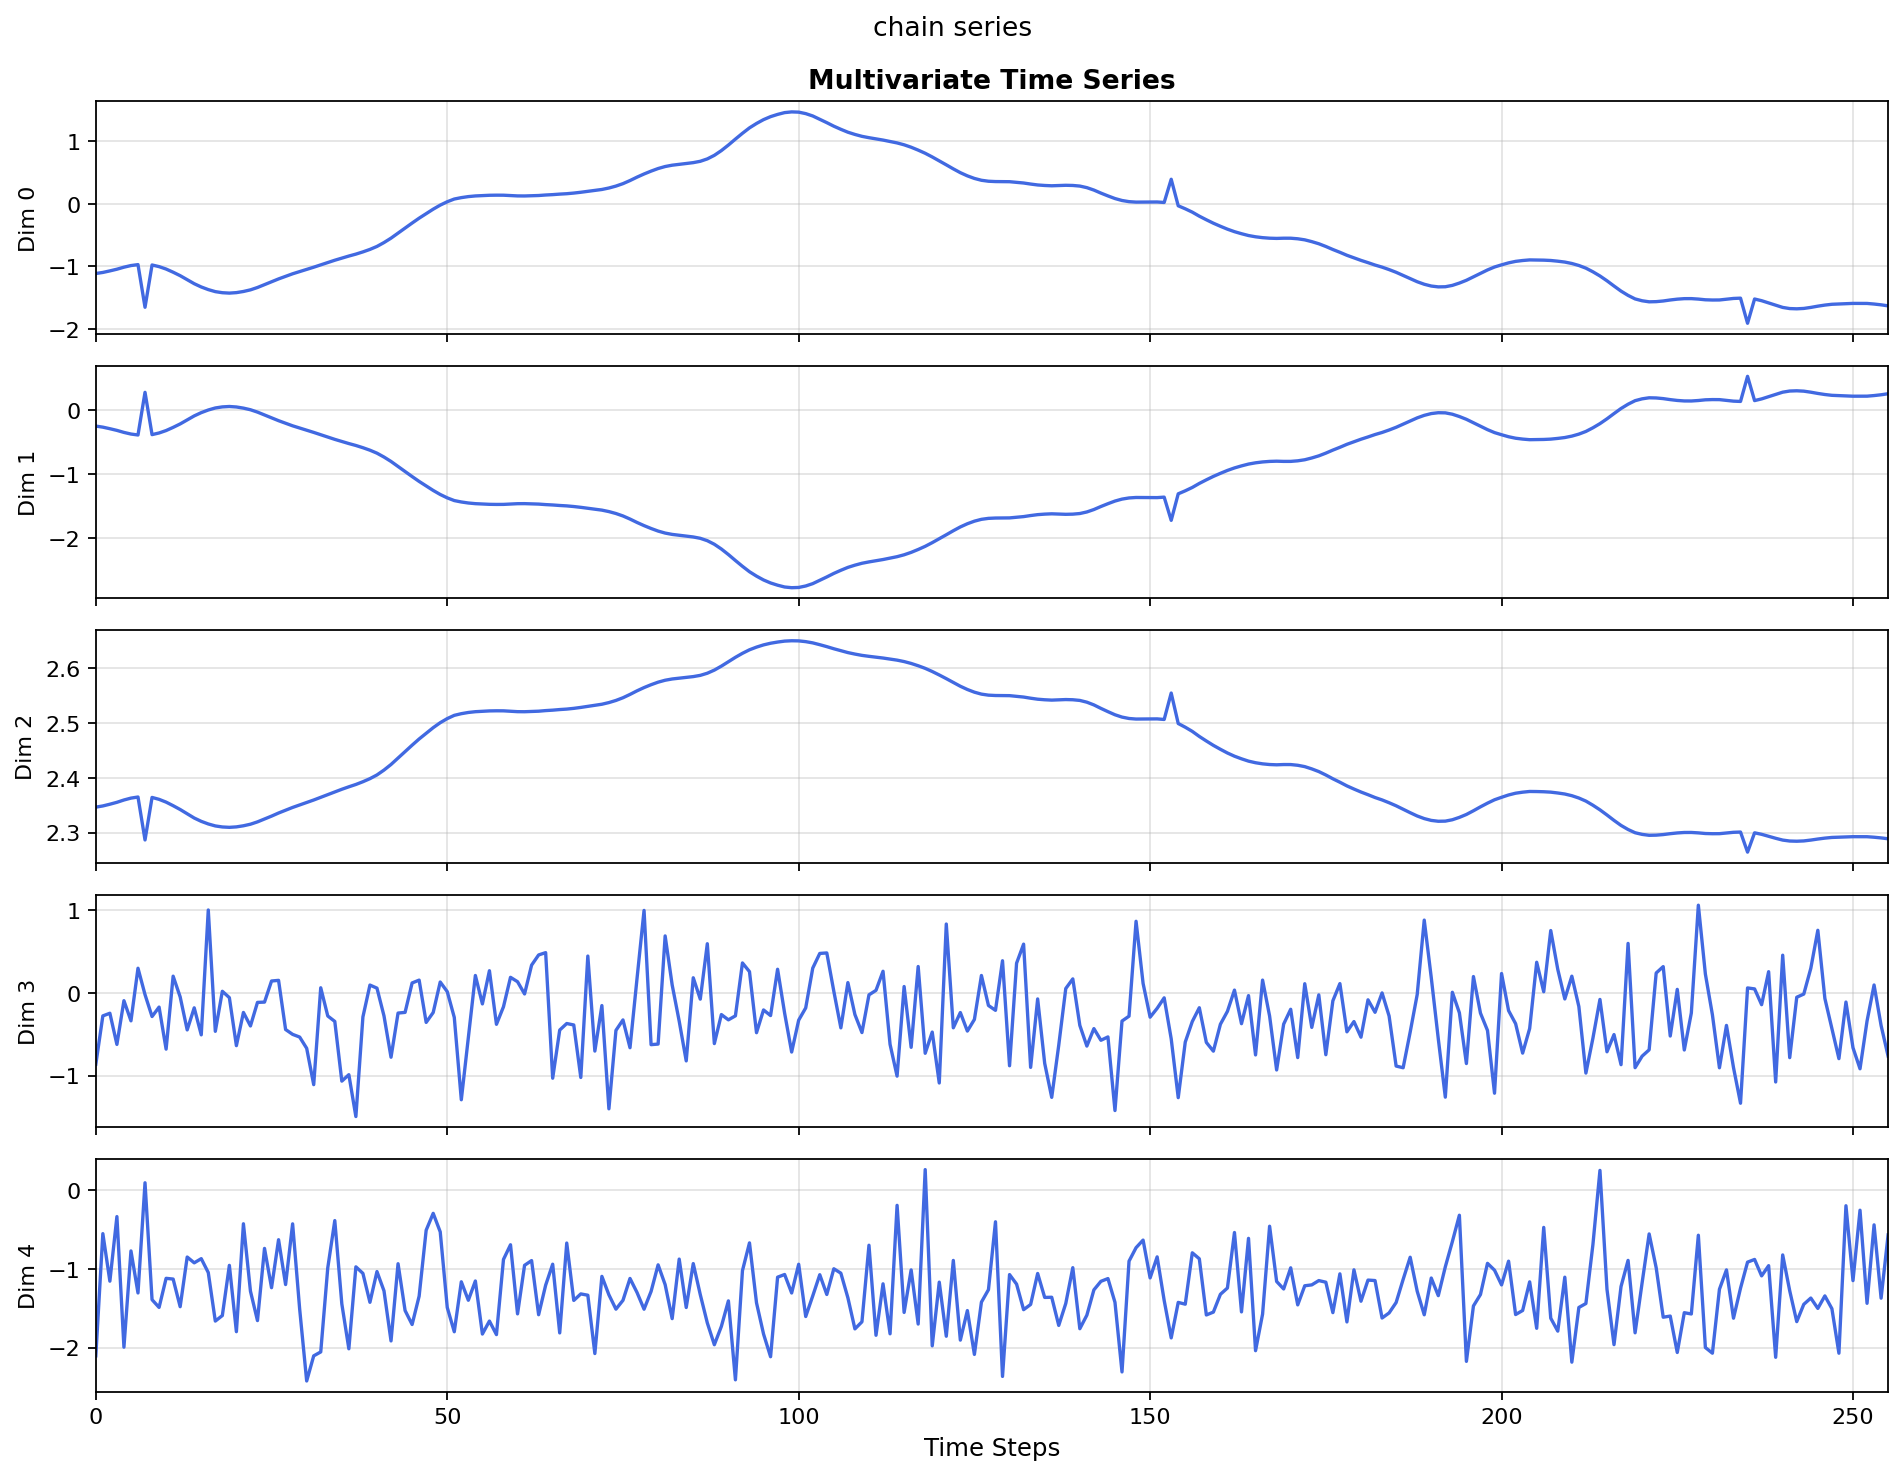

fork: adjacency (4, 4), series (4, 256)


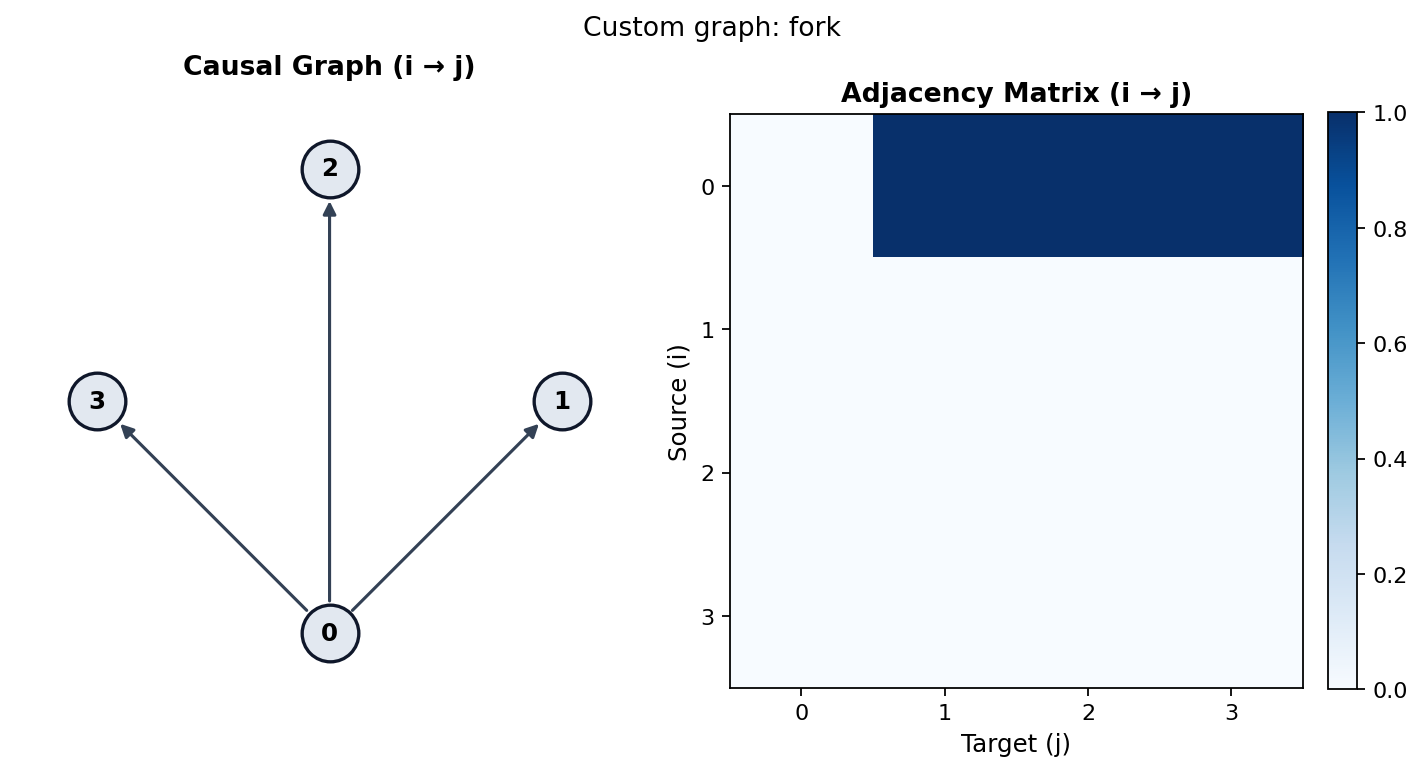

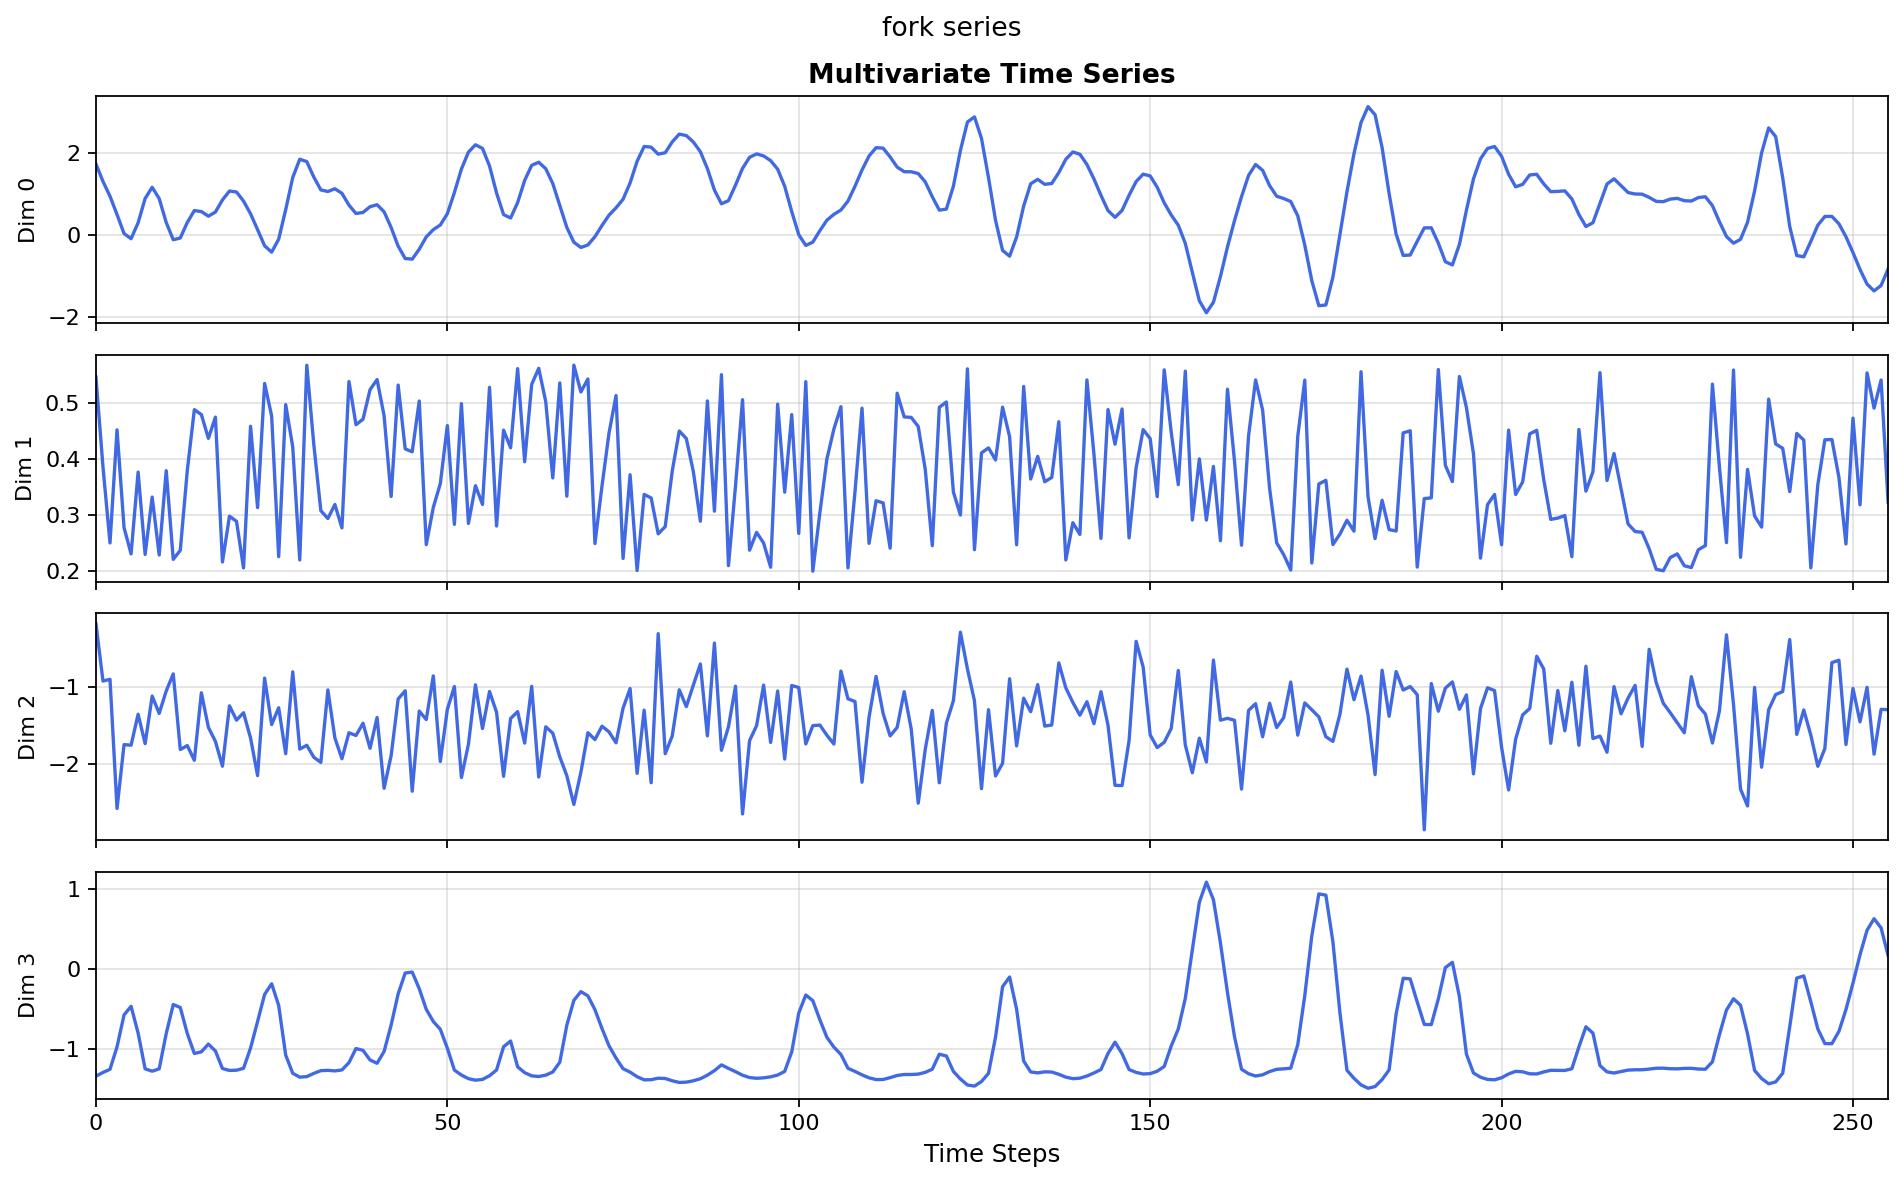

collider: adjacency (4, 4), series (4, 256)


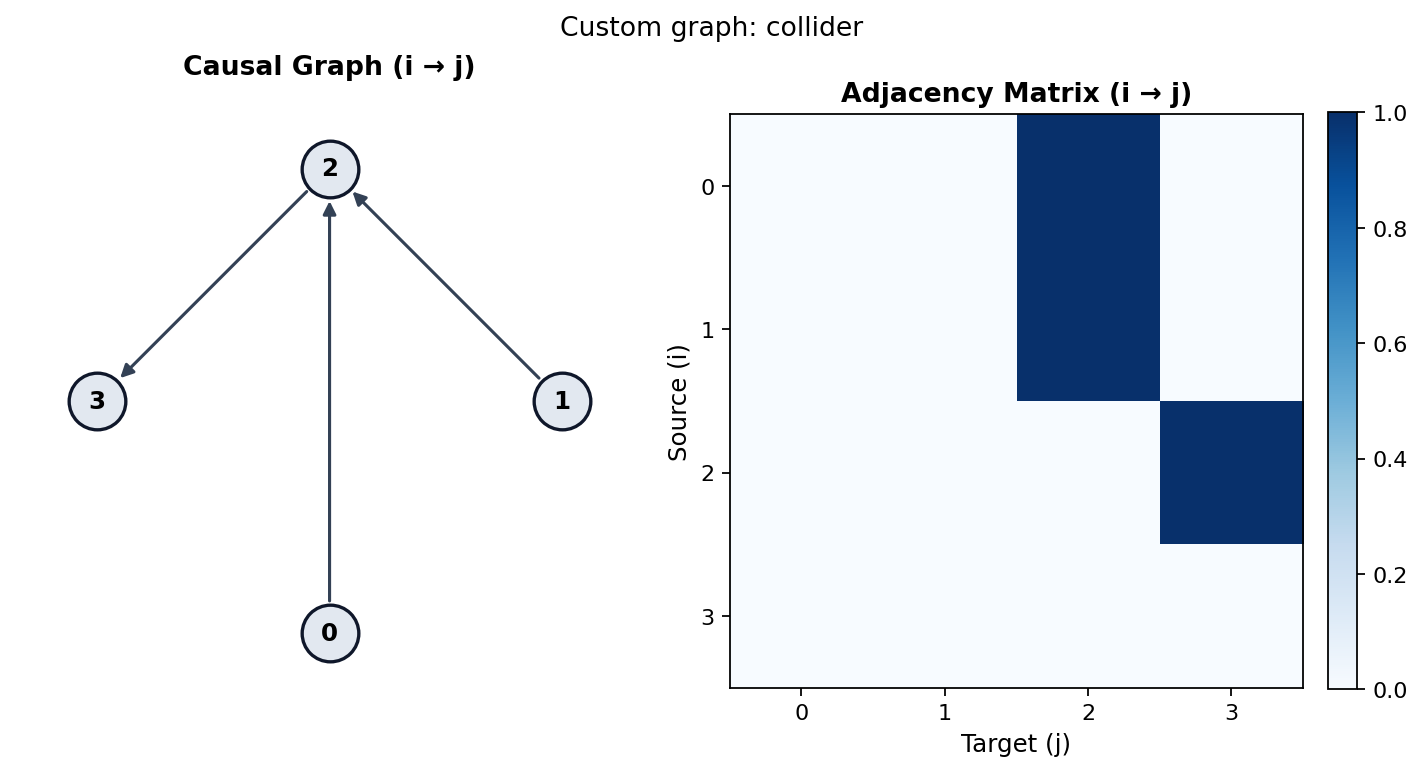

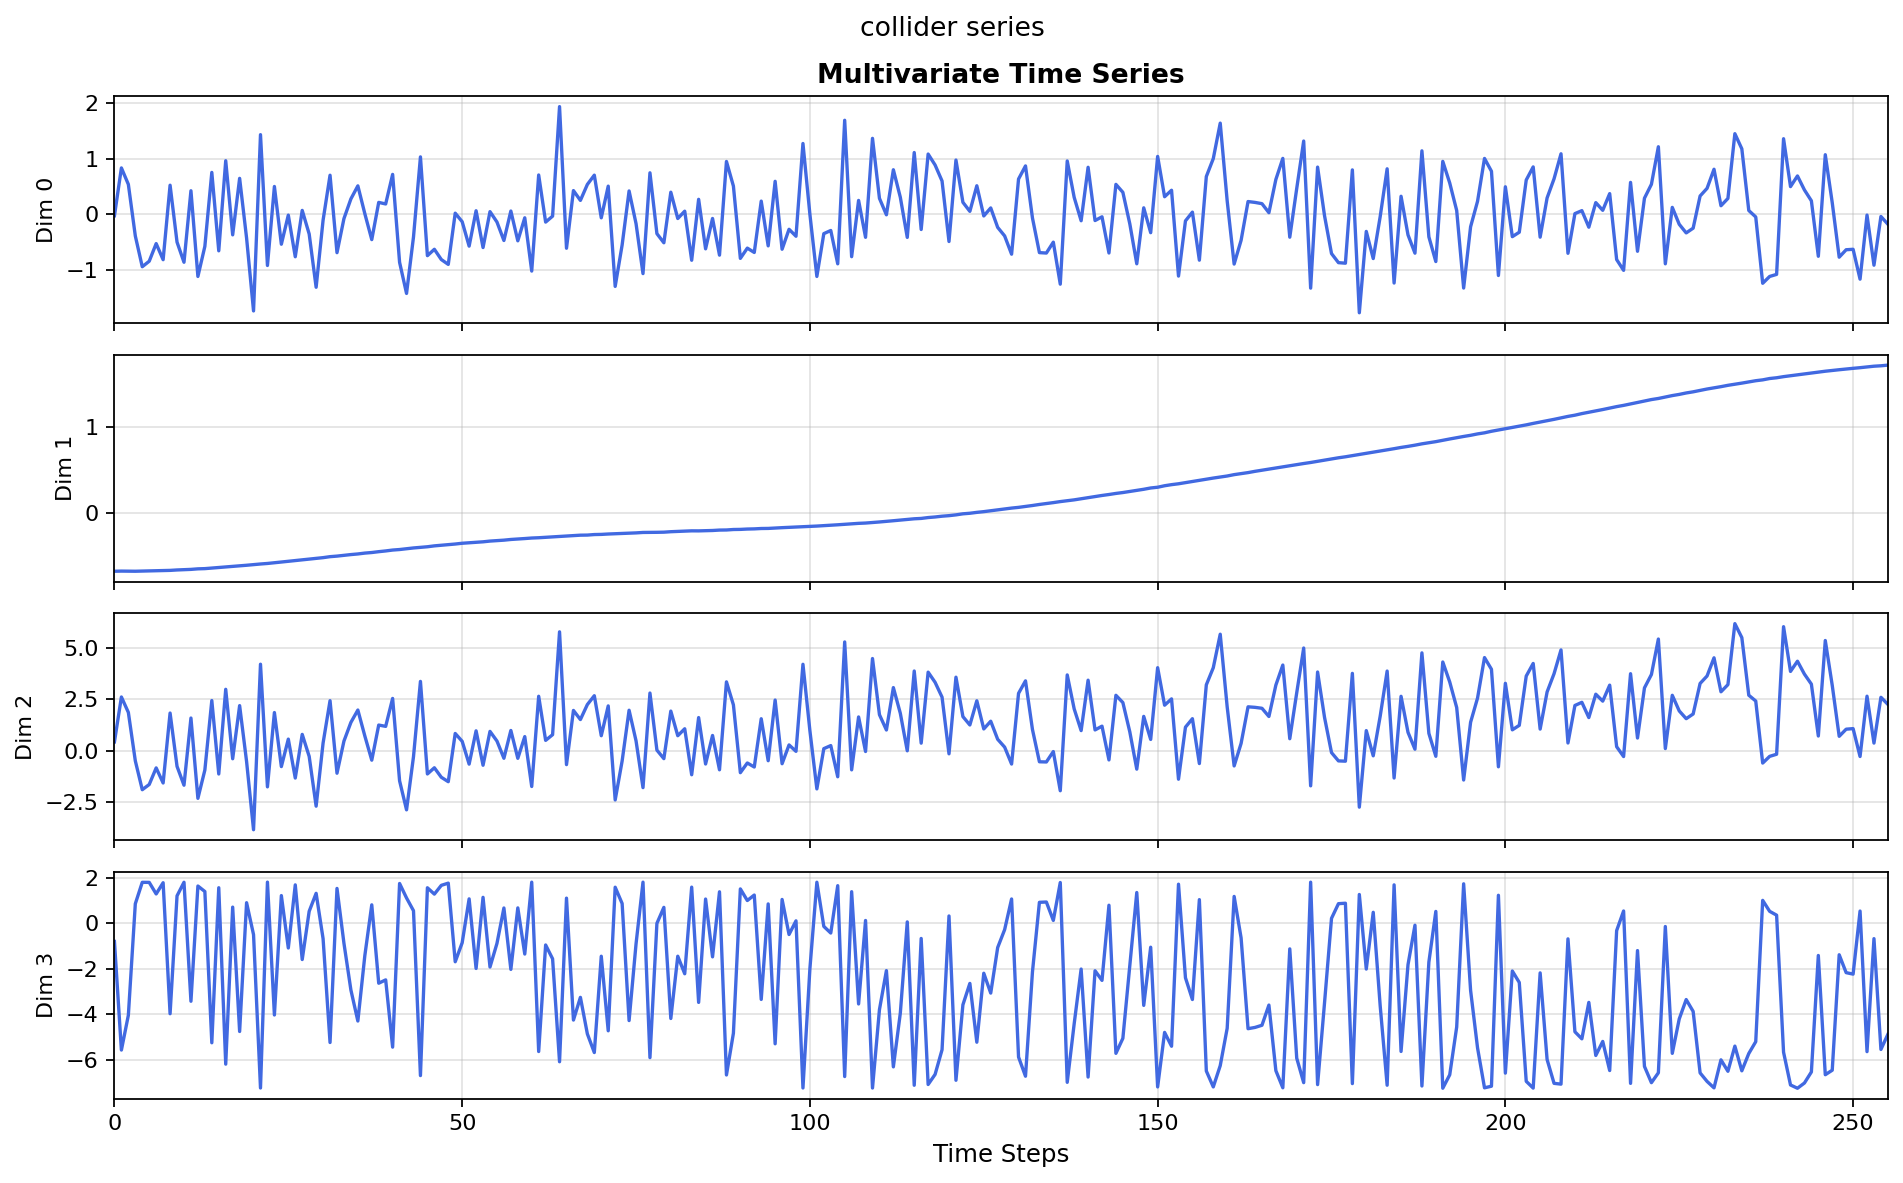

In [4]:
def chain_adj(V: int = 4) -> np.ndarray:
    # 0 -> 1 -> 2 -> ... -> V-1
    adj = np.zeros((V, V), dtype=int)
    for i in range(V - 1):
        adj[i, i + 1] = 1
    return adj


def fork_adj() -> np.ndarray:
    # 0 -> 1, 0 -> 2, 0 -> 3  (common cause)
    adj = np.zeros((4, 4), dtype=int)
    adj[0, 1] = adj[0, 2] = adj[0, 3] = 1
    return adj


def collider_adj() -> np.ndarray:
    # 0 -> 2 <- 1, and 2 -> 3  (collider at 2)
    adj = np.zeros((4, 4), dtype=int)
    adj[0, 2] = adj[1, 2] = adj[2, 3] = 1
    return adj


custom_graphs = {
    "chain": chain_adj(5),
    "fork": fork_adj(),
    "collider": collider_adj(),
}

rng = np.random.RandomState(2)
custom_series = {}
for name, adj in custom_graphs.items():
    V = adj.shape[0]
    x = pipe.generate(rng, seq_length=256, num_channels=V, adjacency=adj)
    custom_series[name] = x
    print(f"{name}: adjacency {adj.shape}, series {x.shape}")

    fig_g = plot_graph(adj, show_matrix=True)
    fig_g.suptitle(f"Custom graph: {name}", y=1.02)
    plt.show()

    fig_x = plot_multivariate_time_series(x)
    fig_x.suptitle(f"{name} series", y=1.02)
    plt.show()

Standalone adjacency heatmap (same convention: row $i$ → column $j$):

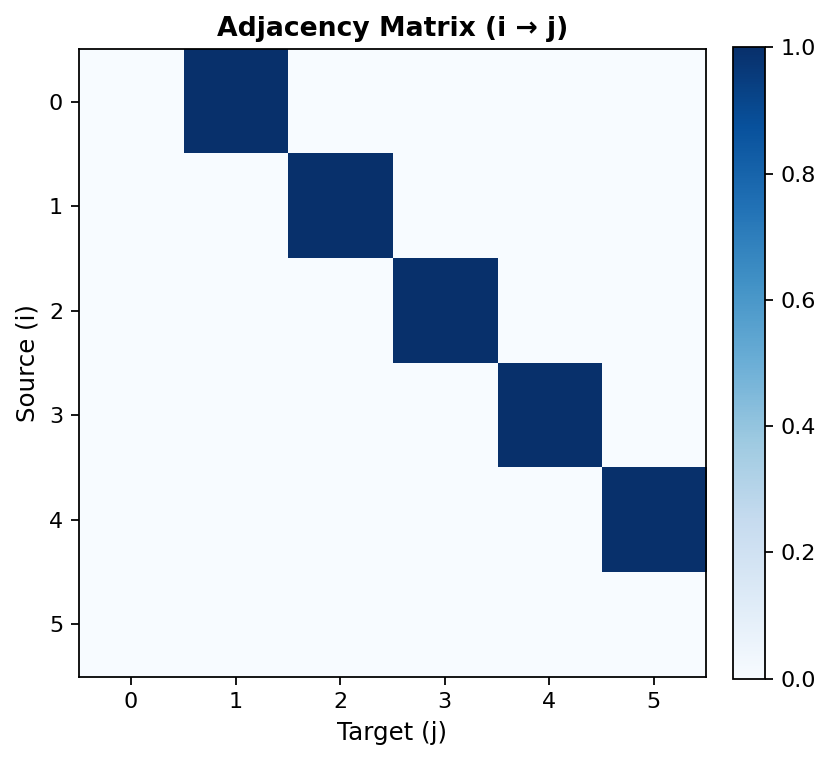

In [5]:
fig = plot_adjacency_matrix(chain_adj(6))
plt.show()

## 4. Channel-wise correlation as a generation check

CauKer injects dependence through the DAG. Pairwise channel metrics on the generated series $x \in \mathbb{R}^{d \times L}$ help verify that:

- **chain**: dependence tends to be stronger between adjacent nodes than distant ones;
- **fork**: children of the common cause share elevated similarity;
- **collider**: parents of a collider need not be strongly dependent with each other, while the child is driven by both.

We use `plot_correlation` / `multivariate_correlation` with Pearson, ACF similarity, power-spectrum similarity, distribution similarity, and Wasserstein distance.

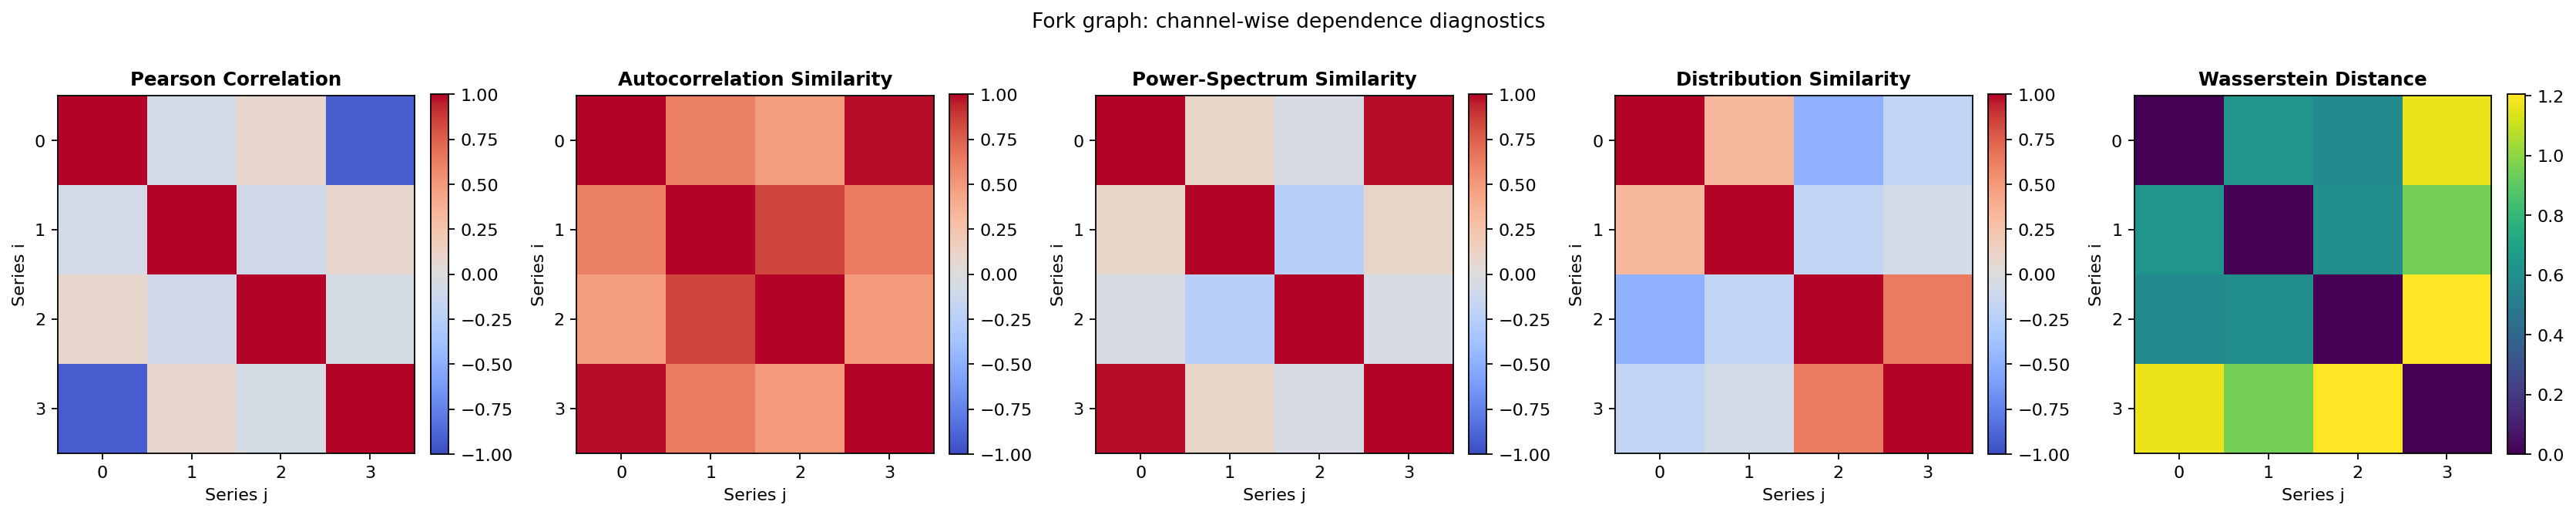


=== chain Pearson ===
[[ 1.    -1.     0.997  0.072 -0.098]
 [-1.     1.    -0.997 -0.072  0.098]
 [ 0.997 -0.997  1.     0.069 -0.099]
 [ 0.072 -0.072  0.069  1.     0.063]
 [-0.098  0.098 -0.099  0.063  1.   ]]

=== fork Pearson ===
[[ 1.    -0.074  0.093 -0.915]
 [-0.074  1.    -0.094  0.088]
 [ 0.093 -0.094  1.    -0.06 ]
 [-0.915  0.088 -0.06   1.   ]]

=== collider Pearson ===
[[ 1.     0.07   0.94  -0.899]
 [ 0.07   1.     0.405 -0.378]
 [ 0.94   0.405  1.    -0.952]
 [-0.899 -0.378 -0.952  1.   ]]


In [6]:
# Multi-metric view on the fork sample (common-cause structure)
x_fork = custom_series["fork"]
fig = plot_correlation(
    x_fork,
    measure="pearson autocorrelation power_spectrum distribution wasserstein",
)
fig.suptitle("Fork graph: channel-wise dependence diagnostics", y=1.05)
plt.show()

# Numeric Pearson snapshot for all three motifs
for name, x in custom_series.items():
    pearson = multivariate_correlation(x, measure="pearson")
    print(f"\n=== {name} Pearson ===")
    print(np.round(pearson, 3))

Compare Pearson heatmaps across the three custom graphs side by side:

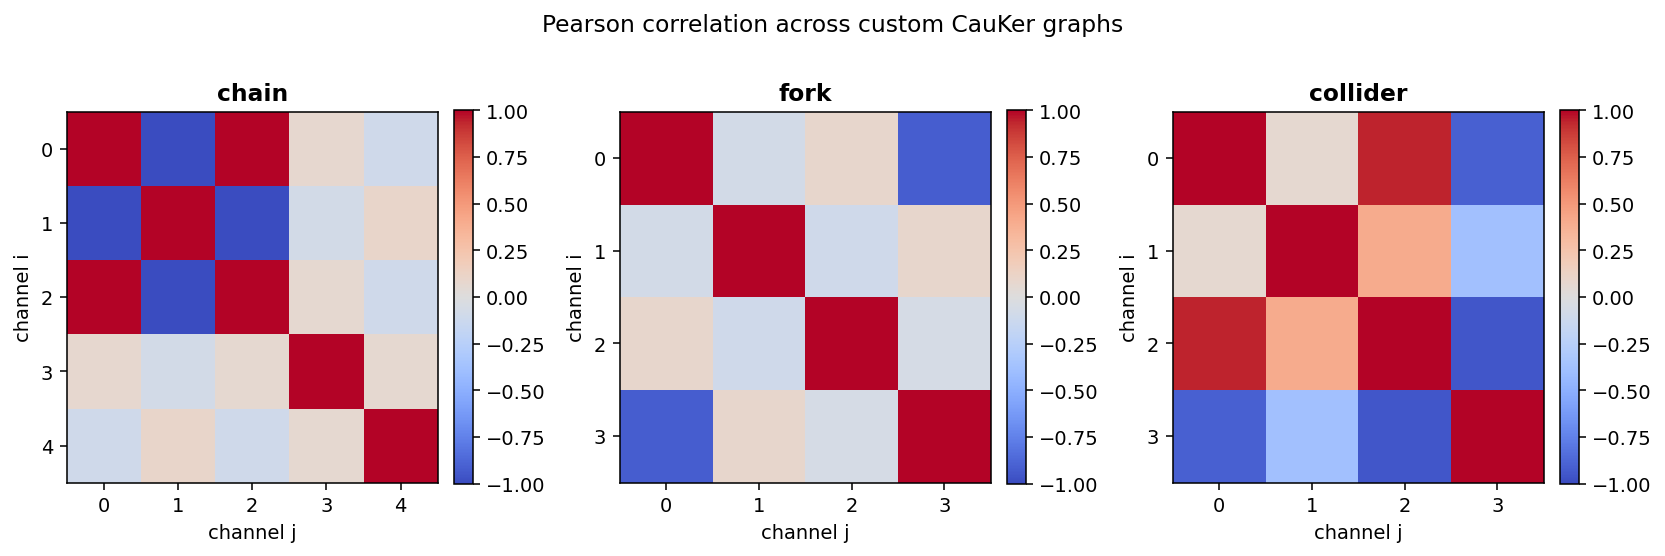

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), dpi=140)
for ax, (name, x) in zip(axes, custom_series.items()):
    mat = multivariate_correlation(x, measure="pearson")
    im = ax.imshow(mat, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(name, fontweight="bold")
    ax.set_xticks(range(x.shape[0]))
    ax.set_yticks(range(x.shape[0]))
    ax.set_xlabel("channel j")
    ax.set_ylabel("channel i")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Pearson correlation across custom CauKer graphs", y=1.02)
fig.tight_layout()
plt.show()

Random-DAG multivariate sample: structure is unknown a priori, but observed channels should still show non-trivial dependence (not near-identity / near-zero off-diagonal).

random DAG: V=20, E=27, observed=[6, 7, 12, 13, 14]


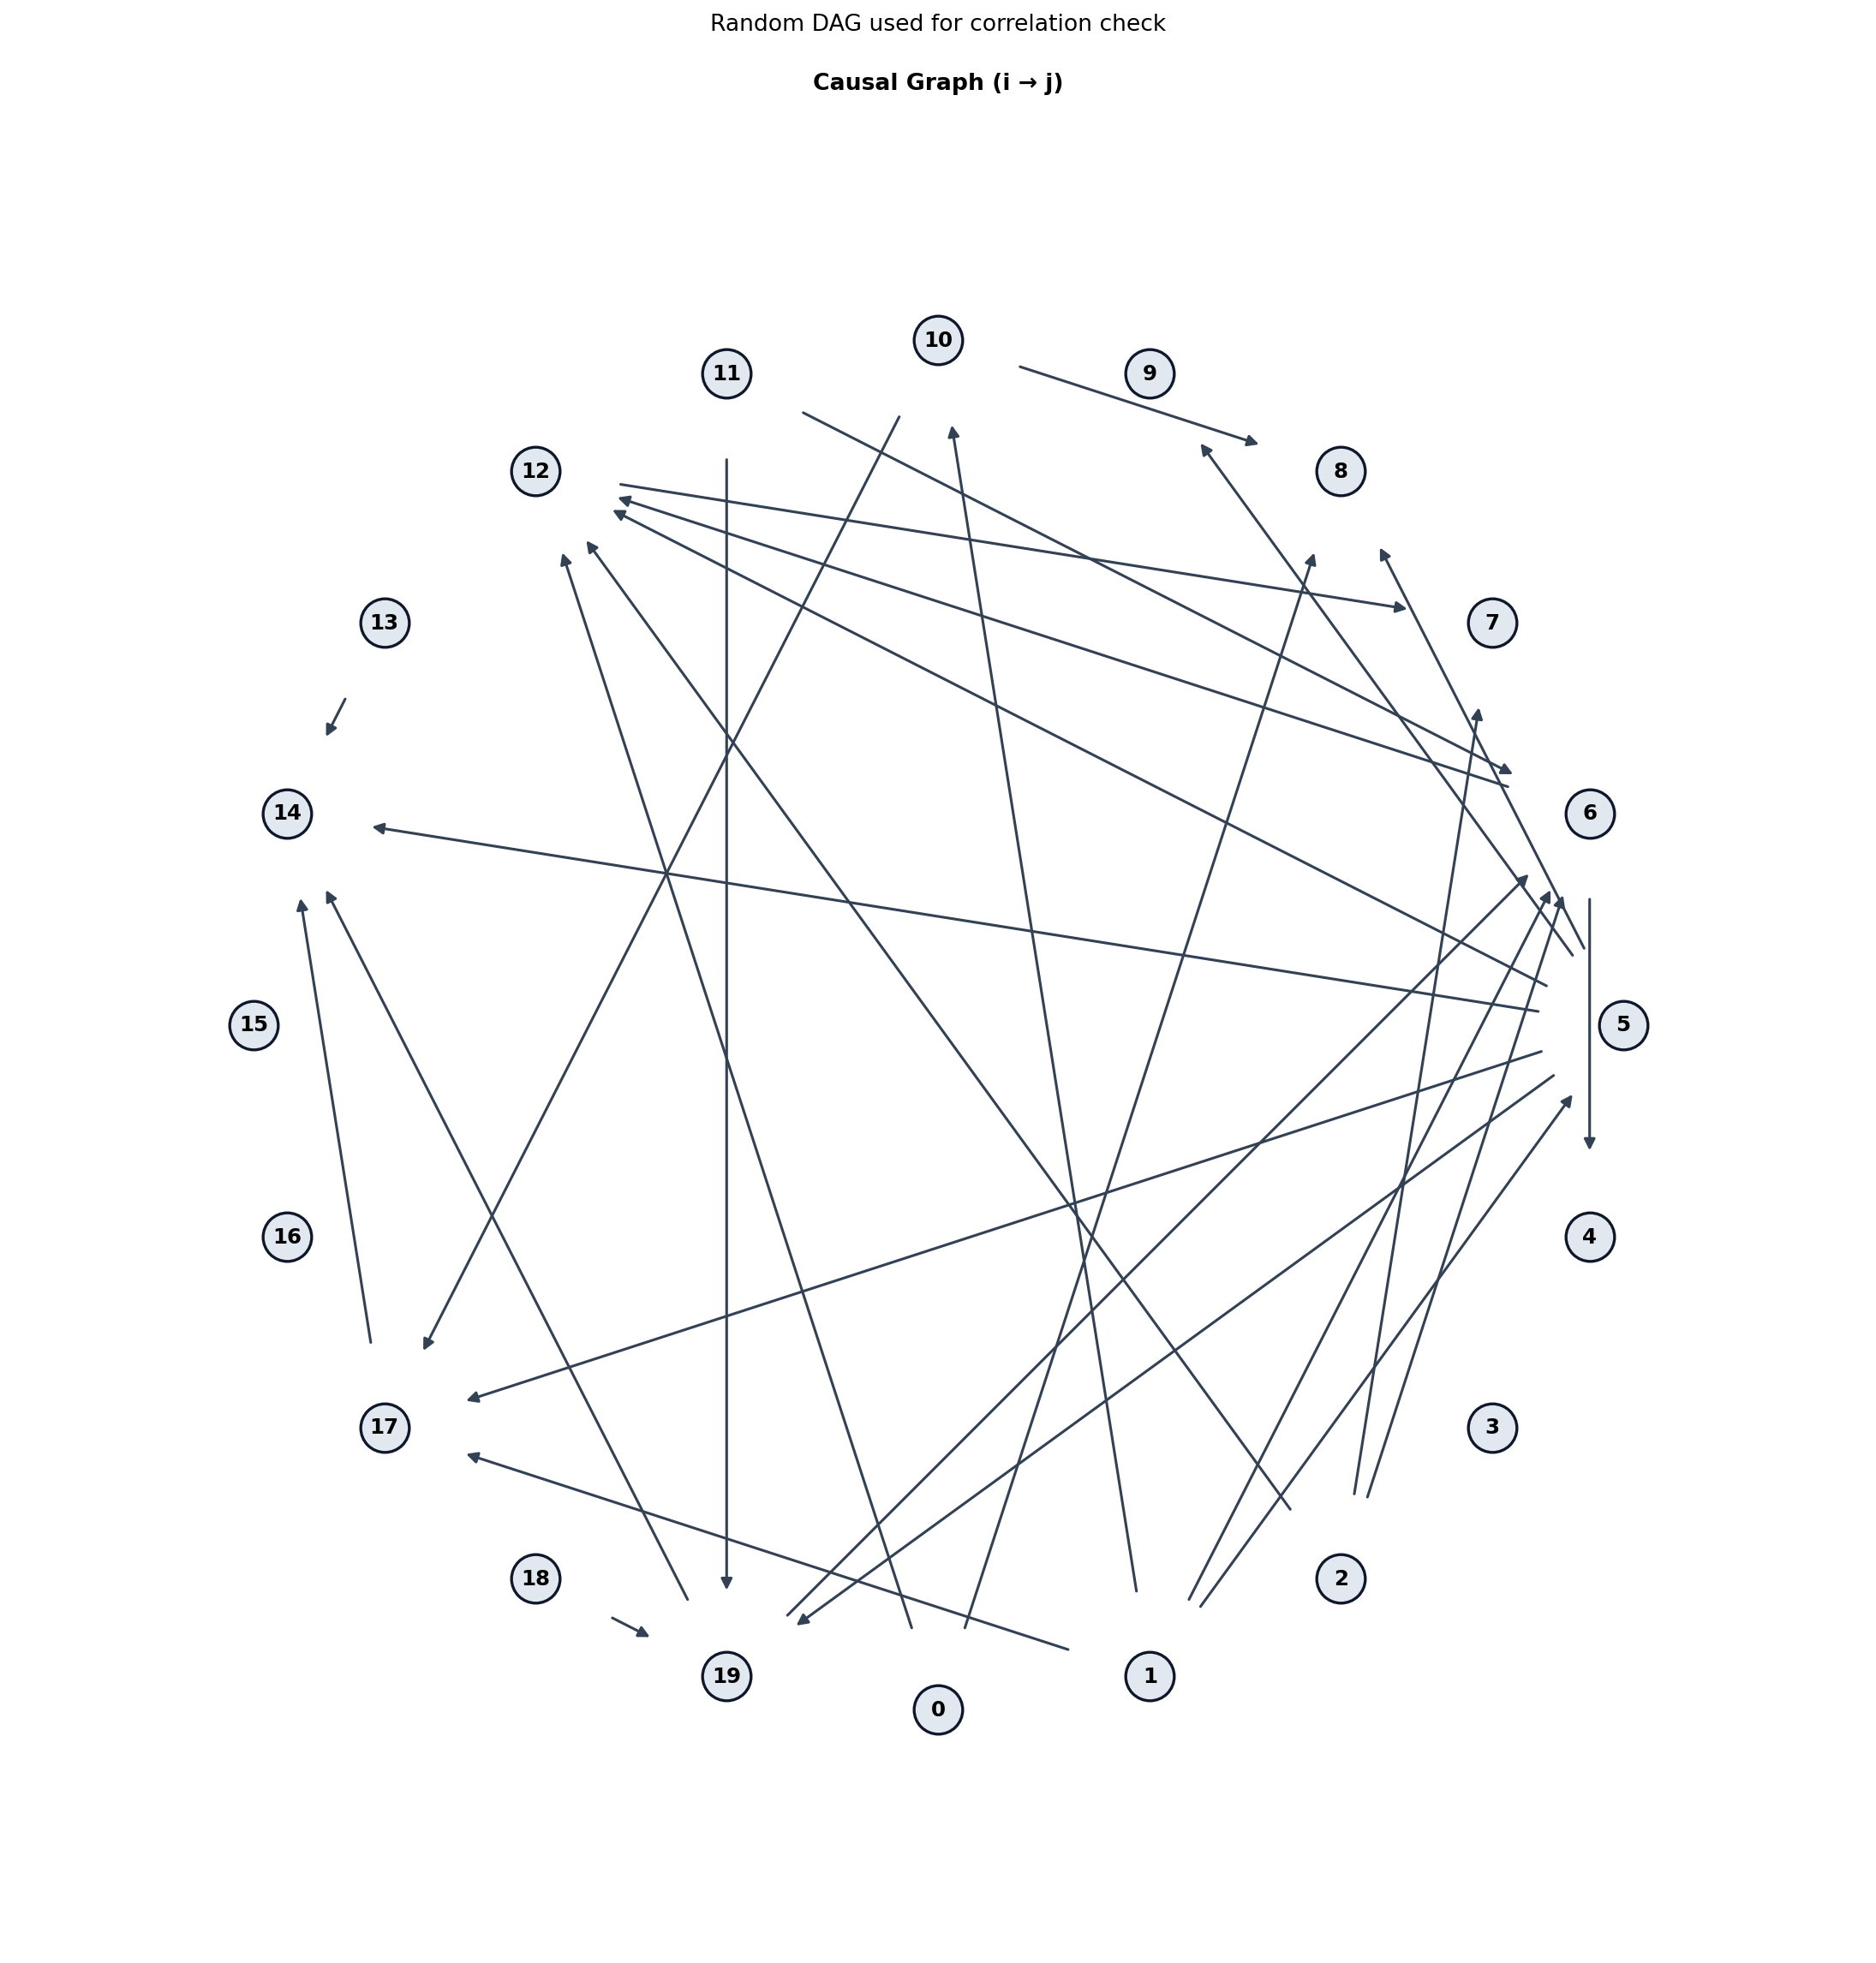

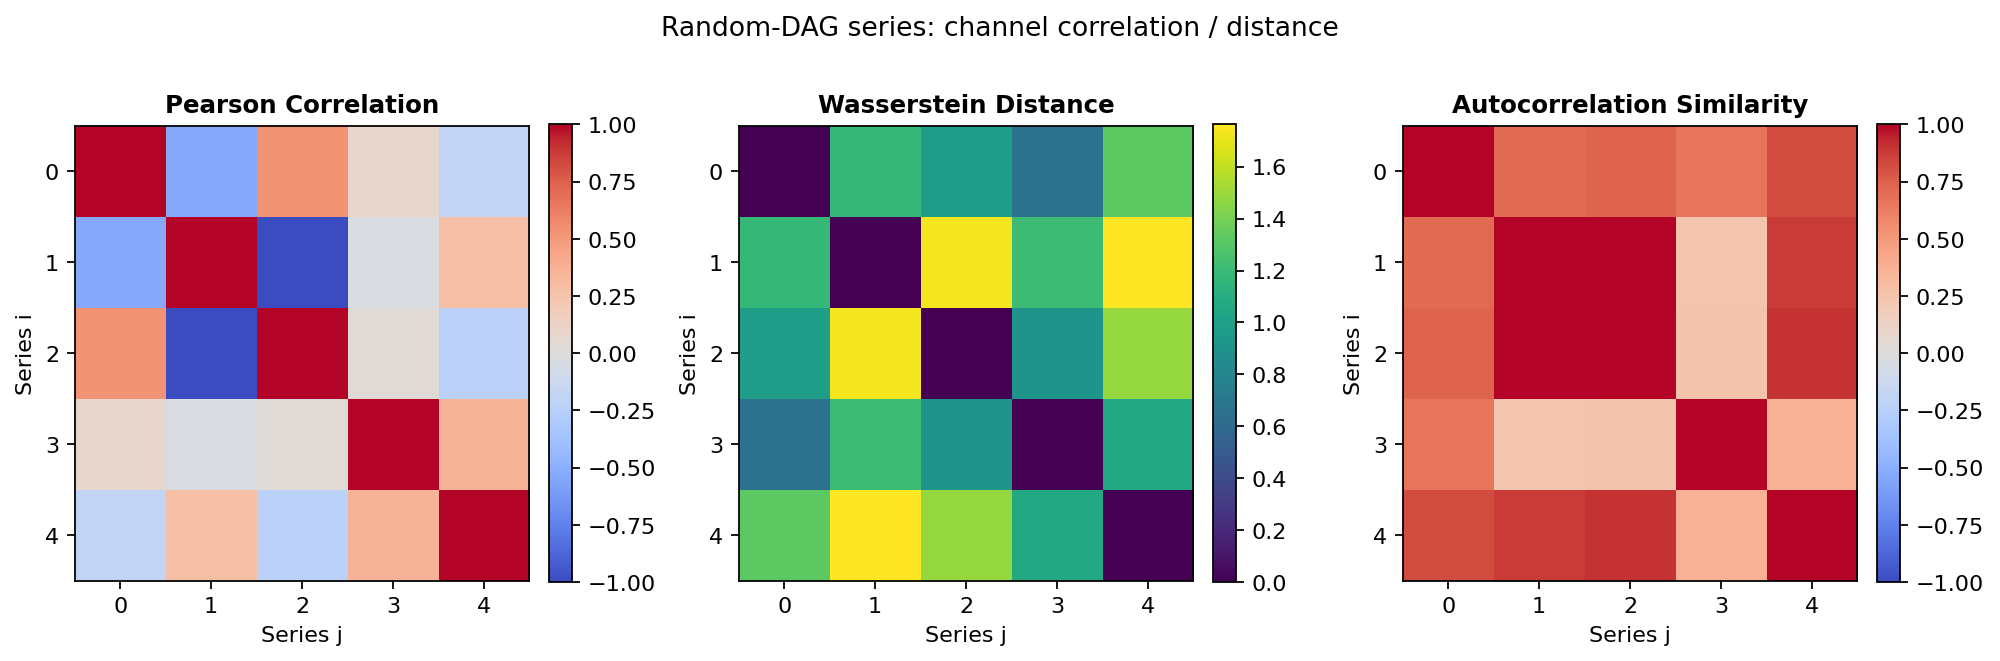

mean |off-diagonal Pearson|: 0.3249343887507473
max  |off-diagonal Pearson|: 0.9950588312787824


In [8]:
rng = np.random.RandomState(7)
x_rand, meta = pipe.generate(rng, seq_length=256, num_channels=5, return_metadata=True)
adj_rand = edges_to_adjacency(meta["n_total_nodes"], meta["edge_list"])
print(
    f"random DAG: V={meta['n_total_nodes']}, E={meta['n_edges']}, "
    f"observed={meta['observed_nodes']}"
)

fig_g = plot_graph(adj_rand, show_matrix=False)
fig_g.suptitle("Random DAG used for correlation check", y=1.02)
plt.show()

fig_c = plot_correlation(x_rand, measure=["pearson", "wasserstein", "acf"])
fig_c.suptitle("Random-DAG series: channel correlation / distance", y=1.05)
plt.show()

pearson_rand = multivariate_correlation(x_rand, measure="pearson")
off = pearson_rand[np.triu_indices_from(pearson_rand, k=1)]
print("mean |off-diagonal Pearson|:", float(np.mean(np.abs(off))))
print("max  |off-diagonal Pearson|:", float(np.max(np.abs(off))))

## 5. Classification labels

CauKer's pre-training objective is classification. Passing `n_classes` returns $(x, y)$ for a single sample. For **balanced** class counts, use `generate_batch`.

In [9]:
rng = np.random.RandomState(3)
x, y = pipe.generate(rng, seq_length=256, num_channels=1, n_classes=5)
print("single labeled sample:", x.shape, "label:", y)

batch = pipe.generate_batch(
    rng, n_samples=40, seq_length=128, num_channels=1, n_classes=4
)
labels = [lab for _, lab in batch]
print("batch size:", len(batch), "| sample shape:", batch[0][0].shape)
print("class counts:", np.bincount(labels))

single labeled sample: (1, 256) label: 0
batch size: 40 | sample shape: (1, 128)
class counts: [10 10 10 10]


## 6. Kernel / mean banks

The pipeline exposes the size of the GP kernel bank and mean-function bank used in steps 1–3.

In [10]:
print("n kernels:", pipe.n_kernels)
print("n mean functions:", pipe.n_mean_functions)

n kernels: 36
n mean functions: 4


## Summary

| API | Role |
| --- | --- |
| `CaukerPipeline.generate` | One series $(d, L)$; optional `adjacency`, `n_classes`, `return_metadata` |
| `CaukerPipeline.generate_batch` | Balanced labeled batch |
| `plot_graph` / `plot_adjacency_matrix` | Causal structure |
| `plot_univariate_time_series` / `plot_multivariate_time_series` | Series visualization |
| `plot_correlation` / `multivariate_correlation` | Channel-wise dependence diagnostics |